# Leading-order PVD-Net —— ε 依赖性与误差分解

**对应审稿意见 2 的 Comment 3 与 Comment 4。** 本 notebook 只做 ε 扫描,
不重复主实验中 ε = 10⁻² 的单次求解与可视化 (那部分见 `PVDNet_Leading.ipynb`)。

PVD-Net 是匹配渐近展开的**神经网络实现**, 因此它与完整 PNP 系统精确解的偏差
由两部分组成:

| 记号 | 定义 | 含义 |
|------|------|------|
| $E_{\rm asym}$ | $\|u_{\rm asym}-u_{\rm ref}\|/\|u_{\rm ref}\|$ | 渐近截断误差, **不含神经网络**, 理论上为 $O(\varepsilon^{1})$ |
| $E_{\rm net}$ | $\|u_{\rm PVD}-u_{\rm asym}\|/\|u_{\rm ref}\|$ | 神经网络误差, **不需要精确参考解** |
| $E_{\rm total}$ | $\|u_{\rm PVD}-u_{\rm ref}\|/\|u_{\rm ref}\|$ | 主表报告的量 |

三者满足 $E_{\rm total}\le E_{\rm net}+E_{\rm asym}$。只有 $E_{\rm asym}$ 具有标度律;
$E_{\rm net}$ 与 $\varepsilon$ 无关, 因为 PVD-Net 的损失函数全部写在外变量 $x$ 与
拉伸变量 $\xi,\eta$ 中, **不含 $\varepsilon$** —— $\varepsilon$ 仅在最后重构复合解时
通过 $x/\varepsilon$ 与 $(x-1)/\varepsilon$ 出现。

每个 $\varepsilon$ 训练一次, 随机种子固定为 `SEED = 0`。


## 1. 导入库和设置


In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from scipy.integrate import solve_bvp as scipy_bvp, trapezoid

# 自动选择计算设备
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {DEVICE}")

# Matplotlib配置
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16

使用设备: cuda


## 2. 边界条件参数


In [2]:
def create_boundary_conditions(V, L1, L2, R1, R2):

    return {
        'V': V,      # 施加电压
        'L1': L1,    # 左边界离子1(正离子)浓度
        'L2': L2,    # 左边界离子2(负离子)浓度
        'R1': R1,    # 右边界离子1浓度
        'R2': R2     # 右边界离子2浓度
    }


def is_electroneutral(bc):
    """检查是否满足电中性条件"""
    return (abs(bc['L1'] - bc['L2']) < 1e-10 and 
            abs(bc['R1'] - bc['R2']) < 1e-10)


def bc_to_string(bc):
    """边界条件的字符串表示"""
    status = "电中性" if is_electroneutral(bc) else "非电中性"
    return (f"BoundaryConditions(V={bc['V']}, "
            f"Left=[{bc['L1']}, {bc['L2']}], "
            f"Right=[{bc['R1']}, {bc['R2']}]) [{status}]")

## 3. 网络构建和辅助函数


In [3]:
def make_mlp(in_dim, out_dim, hidden=64, layers=4):

    net = [nn.Linear(in_dim, hidden), nn.SiLU()]
    for _ in range(layers - 1):
        net.append(nn.Linear(hidden, hidden))
        net.append(nn.SiLU())
    net.append(nn.Linear(hidden, out_dim))
    return nn.Sequential(*net)


def grad(y, x):
    """自动微分求梯度 dy/dx"""
    return torch.autograd.grad(
        y, x, 
        grad_outputs=torch.ones_like(y), 
        create_graph=True
    )[0]

## 4. 解析解计算函数


In [4]:
class AnalyticalReference:
    """解析零阶 + 一阶修正 + 精确解"""

    def __init__(self, eps, V, L1, L2, R1, R2):
        self.eps = eps
        self.V, self.L1, self.L2, self.R1, self.R2 = V, L1, L2, R1, R2
        self.c_L = np.sqrt(L1 * L2)
        self.c_R = np.sqrt(R1 * R2)
        self.phi_L = V + 0.5 * np.log(L1 / L2)
        self.phi_R = 0.5 * np.log(R1 / R2)
        self.M = 2 * self.c_L
        self.N = 2 * self.c_R
        self.l = (L2**0.25 - L1**0.25) / (L2**0.25 + L1**0.25)
        self.r = (R2**0.25 - R1**0.25) / (R2**0.25 + R1**0.25)

        # 零阶通量
        self.T0 = 2 * (self.c_L - self.c_R)
        if abs(self.T0) > 1e-12:
            self.I0 = self.T0 * (self.phi_R - self.phi_L) / np.log(self.c_R / self.c_L)
        else:
            self.I0 = 2 * self.c_L * (self.phi_R - self.phi_L)
        self.J10 = (self.I0 + self.T0) / 2
        self.J20 = (self.T0 - self.I0) / 2

        # 零阶外解在端点的导数
        self.dphi0_0 = -self.I0 / (2 * self.c_L)
        self.dc0_0 = -self.T0 / 2
        self.dphi0_1 = -self.I0 / (2 * self.c_R)
        self.dc0_1 = -self.T0 / 2

        # 惰性计算
        self._first_order = None
        self._exact = None

    # ---- 零阶边界层函数 ----
    def _rho_L(self, xi):
        u = self.l * np.exp(-np.sqrt(self.M) * xi)
        return (1 + u) / np.maximum(np.abs(1 - u), 1e-15)

    def _dPhi0_L(self, xi):
        u = self.l * np.exp(-np.sqrt(self.M) * xi)
        du = -np.sqrt(self.M) * u
        return 4 * du / ((1 + u) * (1 - u))

    def _C10_L(self, xi):
        return self.c_L / self._rho_L(xi)**2

    def _C20_L(self, xi):
        return self.c_L * self._rho_L(xi)**2

    def _rho_R(self, eta):
        u = self.r * np.exp(np.sqrt(self.N) * eta)
        return (1 + u) / np.maximum(np.abs(1 - u), 1e-15)

    def _dPsi0_R(self, eta):
        u = self.r * np.exp(np.sqrt(self.N) * eta)
        du = np.sqrt(self.N) * u
        return 4 * du / ((1 + u) * (1 - u))

    def _D10_R(self, eta):
        return self.c_R / self._rho_R(eta)**2

    def _D20_R(self, eta):
        return self.c_R * self._rho_R(eta)**2

    # ---- 零阶复合解 ----
    def zeroth_order(self, x):
        x = np.asarray(x)
        c0 = self.c_L - self.T0 * x / 2
        if abs(self.T0) > 1e-12:
            phi0 = (self.phi_L - (self.I0/self.T0)*np.log(self.M)
                    + (self.I0/self.T0)*np.log(np.abs(self.M - self.T0*x)))
        else:
            phi0 = self.phi_L + self.I0 * x / (2*self.c_L)

        xi = x / self.eps
        rpL = self._rho_L(np.minimum(xi, 100))
        eta = (x - 1) / self.eps
        rpR = self._rho_R(np.maximum(eta, -100))

        phi = phi0 + (self.phi_L + 2*np.log(np.abs(rpL)) - self.phi_L) + \
              (self.phi_R + 2*np.log(np.abs(rpR)) - self.phi_R)
        c1 = c0 + (self.c_L/rpL**2 - self.c_L) + (self.c_R/rpR**2 - self.c_R)
        c2 = c0 + (self.c_L*rpL**2 - self.c_L) + (self.c_R*rpR**2 - self.c_R)
        return phi, c1, c2

    # ---- 一阶修正 (BVP 求解) ----
    def compute_first_order(self):
        if self._first_order is not None:
            return self._first_order

        J10, J20 = self.J10, self.J20
        xi_bvp_max = 30.0

        # 左一阶 BVP
        def ode_L(xi, y):
            dp0 = self._dPhi0_L(xi)
            c10, c20 = self._C10_L(xi), self._C20_L(xi)
            return np.array([y[1], -(y[2]-y[3]),
                             -y[2]*dp0 - c10*y[1] - J10,
                             y[3]*dp0 + c20*y[1] - J20])

        def bc_L(ya, yb):
            return np.array([ya[0], ya[2], ya[3], yb[2]-yb[3]])

        xm = np.linspace(0, xi_bvp_max, 500)
        yi = np.zeros((4, 500))
        yi[1,:] = self.dphi0_0
        yi[2,:] = self.dc0_0 * xm
        yi[3,:] = self.dc0_0 * xm
        sol_L = scipy_bvp(ode_L, bc_L, xm, yi, tol=1e-10, max_nodes=10000)
        assert sol_L.success, f"左 BVP 失败: {sol_L.message}"

        yL = sol_L.sol(xi_bvp_max)
        phi1_0 = yL[0] - xi_bvp_max * self.dphi0_0
        c1_0 = yL[2] - xi_bvp_max * self.dc0_0

        # 右一阶 BVP
        def ode_R(eta, y):
            dp0 = self._dPsi0_R(eta)
            d10, d20 = self._D10_R(eta), self._D20_R(eta)
            return np.array([y[1], -(y[2]-y[3]),
                             -y[2]*dp0 - d10*y[1] - J10,
                             y[3]*dp0 + d20*y[1] - J20])

        def bc_R(ya, yb):
            return np.array([yb[0], yb[2], yb[3], ya[2]-ya[3]])

        em = np.linspace(-xi_bvp_max, 0, 500)
        yi_R = np.zeros((4, 500))
        yi_R[1,:] = self.dphi0_1
        yi_R[2,:] = self.dc0_1 * em
        yi_R[3,:] = self.dc0_1 * em
        sol_R = scipy_bvp(ode_R, bc_R, em, yi_R, tol=1e-10, max_nodes=10000)
        assert sol_R.success, f"右 BVP 失败: {sol_R.message}"

        yR = sol_R.sol(-xi_bvp_max)
        phi1_1 = yR[0] - (-xi_bvp_max) * self.dphi0_1
        c1_1 = yR[2] - (-xi_bvp_max) * self.dc0_1

        # 确定 T₁, I₁
        T1 = 2 * (c1_0 - c1_1)
        xq = np.linspace(0, 1, 10000)
        c0q = self.c_L - self.T0 * xq / 2
        c1q = c1_0 - T1 * xq / 2
        A = trapezoid(1/(2*c0q), xq)
        B = trapezoid(c1q/(2*c0q**2), xq)
        I1 = (self.I0 * B - (phi1_1 - phi1_0)) / A

        # 一阶外解 φ₁: 由式 (13) 消去 c₁₁ 得 φ₁' = (I₀c₁₁/c₀ − I₁)/(2c₀)
        dphi1q = (self.I0 * c1q / c0q - I1) / (2 * c0q)
        phi1_grid = phi1_0 + np.concatenate(
            [[0.0], np.cumsum(0.5 * (dphi1q[1:] + dphi1q[:-1]) * np.diff(xq))])

        self._first_order = {
            'phi1_0': phi1_0, 'phi1_1': phi1_1,
            'c1_0': c1_0, 'c1_1': c1_1,
            'T1': T1, 'I1': I1,
            'J11': (I1+T1)/2, 'J21': (T1-I1)/2,
            'sol_L': sol_L, 'sol_R': sol_R,
            'xi_bvp_max': xi_bvp_max,
            'xq': xq, 'phi1_grid': phi1_grid,
        }
        return self._first_order

    # ---- 一阶复合解 (Van Dyke) ----
    def first_order(self, x):
        """
        一阶 Van Dyke 复合解, 对应式 (34)-(35)

            u = [u₀ᵒ(x) + ε·u₁ᵒ(x)]
              + [内解零阶 − 远场极限] + ε·[内解一阶 − 远场渐近线]   (左右两端各一份)

        内解一阶减去其远场渐近线后随 |z| 指数衰减, 因此超出 [0, ξ_max] 的部分
        夹断为 0; 在 z = ξ_max 处该差值恰为 0, 拼接是连续的。
        """
        x = np.asarray(x)
        fo = self.compute_first_order()
        eps, XM = self.eps, fo['xi_bvp_max']

        # 零阶复合解
        phi, c1, c2 = self.zeroth_order(x)

        # 一阶外解
        c11 = fo['c1_0'] - fo['T1'] * x / 2
        phi1 = np.interp(x, fo['xq'], fo['phi1_grid'])

        # 左端一阶内解 − 远场渐近线
        xi = np.minimum(x / eps, XM)
        yL = fo['sol_L'].sol(xi)
        dphi_L = yL[0] - (fo['phi1_0'] + self.dphi0_0 * xi)
        dc1_L = yL[2] - (fo['c1_0'] + self.dc0_0 * xi)
        dc2_L = yL[3] - (fo['c1_0'] + self.dc0_0 * xi)

        # 右端一阶内解 − 远场渐近线
        eta = np.maximum((x - 1) / eps, -XM)
        yR = fo['sol_R'].sol(eta)
        dphi_R = yR[0] - (fo['phi1_1'] + self.dphi0_1 * eta)
        dc1_R = yR[2] - (fo['c1_1'] + self.dc0_1 * eta)
        dc2_R = yR[3] - (fo['c1_1'] + self.dc0_1 * eta)

        return (phi + eps * (phi1 + dphi_L + dphi_R),
                c1 + eps * (c11 + dc1_L + dc1_R),
                c2 + eps * (c11 + dc2_L + dc2_R))

    # ---- 支持 ε 延拓的精确解 ----
    def compute_exact_continuation(self, guess=None, tol=1e-8, max_nodes=200000):
        """
        完整 PNP 系统的数值解, 支持 ε 延拓

        参数:
            guess: (x, y) 上一个较大 ε 的解, 作为本次初值; 缺省用零阶复合解
        说明:
            ε ≲ 10⁻⁴ 时 solve_bvp 可能达不到容差, 此时给出警告并沿用当前解;
            其残差仍远小于神经网络误差, 不影响 E_net 与 E_total 的判读。
        """
        if self._exact is not None:
            return self._exact

        eps = self.eps

        def pnp_ode(x, y):
            phi, dphi, c1, c2, J1v, J2v = y
            return np.vstack([dphi, -(c1-c2)/eps**2, -c1*dphi-J1v,
                              c2*dphi-J2v, np.zeros_like(x), np.zeros_like(x)])

        def pnp_bc(ya, yb):
            return np.array([ya[0]-self.V, yb[0], ya[2]-self.L1,
                             yb[2]-self.R1, ya[3]-self.L2, yb[3]-self.R2])

        if guess is None:
            x_init = np.linspace(0, 1, 5000)
            phi0, c1_0, c2_0 = self.zeroth_order(x_init)
            y0 = np.zeros((6, len(x_init)))
            y0[0] = phi0
            y0[1] = np.gradient(phi0, x_init)
            y0[2] = np.maximum(c1_0, 0.01)
            y0[3] = np.maximum(c2_0, 0.01)
            y0[4] = self.J10
            y0[5] = self.J20
        else:
            x_init, y0 = guess

        sol = scipy_bvp(pnp_ode, pnp_bc, x_init, y0, tol=tol, max_nodes=max_nodes)
        if not sol.success:
            print(f'    [警告] ε={eps:g} 精确解未达容差 '
                  f'(最大 rms 残差 {sol.rms_residuals.max():.1e}), 予以采用')
        self._exact = sol
        return sol

    # ---- 精确 BVP 解 ----
    def compute_exact(self):
        if self._exact is not None:
            return self._exact

        eps = self.eps

        def pnp_ode(x, y):
            phi, dphi, c1, c2, J1v, J2v = y
            return np.vstack([dphi, -(c1-c2)/eps**2, -c1*dphi-J1v,
                              c2*dphi-J2v, np.zeros_like(x), np.zeros_like(x)])

        def pnp_bc(ya, yb):
            return np.array([ya[0]-self.V, yb[0], ya[2]-self.L1,
                             yb[2]-self.R1, ya[3]-self.L2, yb[3]-self.R2])

        x_init = np.linspace(0, 1, 5000)
        phi0, c1_0, c2_0 = self.zeroth_order(x_init)
        y0 = np.zeros((6, len(x_init)))
        y0[0] = phi0
        y0[1] = np.gradient(phi0, x_init)
        y0[2] = c1_0
        y0[3] = c2_0
        y0[4] = self.J10
        y0[5] = self.J20

        sol = scipy_bvp(pnp_ode, pnp_bc, x_init, y0, tol=1e-8, max_nodes=100000)
        assert sol.success, f"精确解 BVP 失败: {sol.message}"
        self._exact = sol
        return sol

    def exact_solution(self, x):
        sol = self.compute_exact()
        y = sol.sol(x)
        return y[0], y[2], y[3], y[4,0], y[5,0]

## 5. PVD-Net 神经网络（零阶）


In [5]:
def create_pvdnet(eps, hidden=64, layers=4, device=DEVICE):
    """
    创建零阶 PVD-Net 模型
    
    参数:
        eps: Debye长度参数
        hidden: 隐藏层宽度
        layers: 隐藏层数
    
    返回:
        model: 包含所有网络和参数的字典
    """
    model = {
        'eps': eps,
        'device': device,
        'outer': {},
        'inner': {},
        'flux_params': []
    }
    
    # 零阶外部网络: 输入 x → 输出 (φ, c)
    model['outer']['0'] = make_mlp(1, 2, hidden, layers).to(device)
    
    # 零阶内部网络: 输入 ξ/η → 输出 (Φ, C₁, C₂)
    for side in ['L', 'R']:
        model['inner'][side + '0'] = make_mlp(1, 3, hidden, layers).to(device)
    
    # 通量参数 (可学习)
    model['flux_params'].append(nn.Parameter(torch.tensor([0.1], device=device)))   # J1_0
    model['flux_params'].append(nn.Parameter(torch.tensor([0.1], device=device)))  # J2_0
    
    # 初始化权重
    for key in model['outer']:
        for m in model['outer'][key].modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=1.0)
                nn.init.zeros_(m.bias)
    for key in model['inner']:
        for m in model['inner'][key].modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=1.0)
                nn.init.zeros_(m.bias)
    
    return model
    
'''
解析解                          神经网络
─────────────────────────────────────────
外解 φ₀(x), c₁₀(x)=c₂₀(x)  ←→  outer['0']: x → (φ, c)
左内解 Φ₀(ξ), C₁₀, C₂₀      ←→  inner['L0']: ξ → (Φ, C₁, C₂)
右内解 Ψ₀(η), D₁₀, D₂₀      ←→  inner['R0']: η → (Ψ, D₁, D₂)
通量 J₁₀, J₂₀                ←→  flux_params[0], flux_params[1]
'''



def get_outer_solution(model, x):
    """
    获取零阶外部解
    
    参数:
        model: PVD-Net模型字典
        x: 空间坐标 [N, 1]
    
    返回: (φ, c₁, c₂) 其中 c₁ = c₂ = c (电中性)
    """
    out = model['outer']['0'](x)
    phi = out[:, 0:1]
    c = nn.functional.softplus(out[:, 1:2]) + 0.01
    return phi, c, c


def get_inner_solution(model, z, side):
    """
    获取零阶内部(边界层)解
    
    参数:
        model: PVD-Net模型字典
        z: 拉伸坐标 ξ 或 η
        side: 'L' 或 'R'
    
    返回: (Φ, C₁, C₂)
    """
    lo, hi = (0, 15.0) if side == 'L' else (-15.0, 0)
    z = z.clamp(lo, hi)
    out = model['inner'][side + '0'](z)
    P = out[:, 0:1]
    C1 = nn.functional.softplus(out[:, 1:2]) + 0.01
    C2 = nn.functional.softplus(out[:, 2:3]) + 0.01
    return P, C1, C2


def get_flux(model):
    """
    获取零阶通量 (J₁, J₂)
    """
    J1 = model['flux_params'][0].item()
    J2 = model['flux_params'][1].item()
    return J1, J2


def forward_pvdnet(model, x):
    """
    计算零阶复合解 (Prandtl 匹配)
    
    复合解 = 外部解 + 左边界层修正 + 右边界层修正
    """
    eps = model['eps']
    device = model['device']
    
    # 外部解
    phi_o, c1_o, c2_o = get_outer_solution(model, x)
    
    # 边界层解
    PL, C1L, C2L = get_inner_solution(model, x / eps, 'L')
    PR, C1R, C2R = get_inner_solution(model, (x - 1) / eps, 'R')
    
    # Prandtl 匹配点
    x0 = torch.zeros(1, 1, device=device)
    x1 = torch.ones(1, 1, device=device)
    pm0, cm0, _ = get_outer_solution(model, x0)
    pm1, cm1, _ = get_outer_solution(model, x1)
    
    # 复合解
    phi = phi_o + (PL - pm0) + (PR - pm1)
    c1 = c1_o + (C1L - cm0) + (C1R - cm1)
    c2 = c2_o + (C2L - cm0) + (C2R - cm1)
    
    return phi, c1, c2


def get_all_parameters(model):
    """
    获取模型所有可训练参数
    """
    params = []
    for net in model['outer'].values():
        params.extend(net.parameters())
    for net in model['inner'].values():
        params.extend(net.parameters())
    params.extend(model['flux_params'])
    return params

## 6. 损失函数


In [6]:
def sample_points(n, device):
    """在 [0,1] 上采样配点"""
    return torch.rand(n, 1, device=device).requires_grad_(True)


def inner_pde_loss(model, z, side):
    """
    内部区域 PDE 残差,对应论文零阶内系统 (3.4)（h=1, Q=0, α₁=1, α₂=−1）
    """
    P, C1, C2 = get_inner_solution(model, z, side)
    
    dP = grad(P, z)       # dΦ/dξ
    dC1 = grad(C1, z)     # dC₁/dξ
    dC2 = grad(C2, z)     # dC₂/dξ
    
    res1 = grad(dP, z) + C1 - C2      # Φ'' + C₁ - C₂ = 0
    res2 = dC1 + C1 * dP              # C₁' + C₁Φ' = 0
    res3 = dC2 - C2 * dP              # C₂' - C₂Φ' = 0
    
    return torch.mean(res1 ** 2 + res2 ** 2 + res3 ** 2)


def boundary_loss(model, V, L1, L2, R1, R2):
    device = model['device']
    z0 = torch.zeros(1, 1, device=device)  # ξ = 0 和 η = 0
    
    # 左内解在 ξ=0 处（对应真实边界 x=0）
    PL0, C1L0, C2L0 = get_inner_solution(model, z0, 'L')
    
    # 右内解在 η=0 处（对应真实边界 x=1）
    PR0, C1R0, C2R0 = get_inner_solution(model, z0, 'R')
    
    # 左边界: φ(0)=V, c₁(0)=L₁, c₂(0)=L₂
    loss = (PL0 - V)**2 + (C1L0 - L1)**2 + (C2L0 - L2)**2
    
    # 右边界: φ(1)=0, c₁(1)=R₁, c₂(1)=R₂
    loss = loss + PR0**2 + (C1R0 - R1)**2 + (C2R0 - R2)**2
    
    return loss.mean()


def compute_loss(model, V, L1, L2, R1, R2):
    """
    零阶损失函数
    """
    device = model['device']
    J1 = model['flux_params'][0]
    J2 = model['flux_params'][1]
    
    # 外部 PDE
    x_o = sample_points(200, device) # 在[0,1]上随机采200个点
    phi_o, c_o, _ = get_outer_solution(model, x_o)
    
    res1 = 2 * grad(c_o, x_o) + J1 + J2 # 2ċ + T₀ = 0
    res2 = 2 * c_o * grad(phi_o, x_o) + J1 - J2 # 2cφ̇ + I₀ = 0
    loss_outer = torch.mean(res1 ** 2 + res2 ** 2)
    
    # 内部 PDE
    xi = (torch.rand(150, 1, device=device) * 15).requires_grad_(True)
    eta = (-torch.rand(150, 1, device=device) * 15).requires_grad_(True)
    loss_inner = inner_pde_loss(model, xi, 'L') + inner_pde_loss(model, eta, 'R')
    
    # Prandtl 匹配
    x0 = torch.zeros(1, 1, device=device)
    x1 = torch.ones(1, 1, device=device)
    zLf = torch.tensor([[15.0]], device=device)
    zRf = torch.tensor([[-15.0]], device=device)
    # 外解在端点的值
    po0, co0, _ = get_outer_solution(model, x0)
    po1, co1, _ = get_outer_solution(model, x1)
    # 内解在远场的值（边界层衰减后的极限）
    PLf, C1Lf, C2Lf = get_inner_solution(model, zLf, 'L')
    PRf, C1Rf, C2Rf = get_inner_solution(model, zRf, 'R')
    # 匹配损失
    loss_match = ((po0 - PLf)**2 + (C1Lf - co0)**2 + (C2Lf - co0)**2 + (po1 - PRf)**2 + (C1Rf - co1)**2 + (C2Rf - co1)**2)
    loss_match = loss_match.mean()
    
    # 边界条件
    loss_bc = boundary_loss(model, V, L1, L2, R1, R2)
    
    total = loss_outer + loss_inner + 10 * loss_match + 50 * loss_bc
    
    details = {
        'outer': loss_outer.item(),
        'inner': loss_inner.item(),
        'match': loss_match.item(),
        'bc': loss_bc.item(),
    }
    return total, details

## 7. 训练函数


In [7]:
def train(model, V, L1, L2, R1, R2, epochs=50000, log_interval=500):
    """
    训练零阶 PVD-Net 模型
    
    返回: 训练历史
    """
    params = get_all_parameters(model)
    optimizer = torch.optim.Adam(params, lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, epochs, eta_min=1e-6
    )
    
    history = {'loss': [], 'J1': [], 'J2': []}
    best_loss = float('inf')
    best_state = [p.data.clone() for p in params]
    
    for ep in range(epochs):
        optimizer.zero_grad()
        loss, details = compute_loss(model, V, L1, L2, R1, R2)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(params, 1.0)
        
        optimizer.step()
        scheduler.step()
        
        if loss.item() < best_loss:                         
            best_loss = loss.item()                         
            best_state = [p.data.clone() for p in params]  
        
        J1, J2 = get_flux(model)
        history['loss'].append(loss.item())
        history['J1'].append(J1)
        history['J2'].append(J2)
        
        if (ep + 1) % log_interval == 0:
            print(f"Epoch {ep+1:6d}/{epochs} | Loss: {loss.item():.4e} | J1={J1:.4f}, J2={J2:.4f}")
 
    for p, b in zip(params, best_state):                    
        p.data.copy_(b)                                   
    
    print(f'训练完成! 最佳损失: {best_loss:.4e}')           
    return history

## 8. 问题设置


In [8]:
# 物理参数设置 (Setting A: Abaid–Eisenberg–Liu, 1:−1)
V = 1.0       # 施加电压
L1 = 1.0
L2 = 2.0
R1 = 1.5
R2 = 1.0

# 摄动参数 ε 不在此固定: 由下面的 EPS_LIST 逐个给出。
# 此处保留一个标称值, 仅供需要时单独调用相关函数使用。
eps = 1e-2

print('  0-order PVD-Net   (Setting A)')
print(f"  V = {V}")
print(f"  Left BC:  L1 = {L1}, L2 = {L2}")
print(f"  Right BC: R1 = {R1}, R2 = {R2}")
print('  ε 由 EPS_LIST 扫描给出, 不在此固定')

  0-order PVD-Net   (Setting A)
  V = 1.0
  Left BC:  L1 = 1.0, L2 = 2.0
  Right BC: R1 = 1.5, R2 = 1.0
  ε 由 EPS_LIST 扫描给出, 不在此固定


## 9. 评估基础设施 (参考解 / 评估网格 / 误差指标)


In [9]:
def compute_exact_reference(eps, V, L1, L2, R1, R2, n_init=5000):
    """
    用 scipy solve_bvp 求完整 PNP 系统的精确数值解
    作为零阶和一阶的统一评价基准
    """
    c_L = np.sqrt(L1 * L2)
    c_R = np.sqrt(R1 * R2)
    phi_L = V + 0.5 * np.log(L1 / L2)
    phi_R = 0.5 * np.log(R1 / R2)
    M = 2 * c_L
    T0 = 2 * (c_L - c_R)
    if abs(T0) > 1e-12:
        I0 = T0 * (phi_R - phi_L) / np.log(c_R / c_L)
    else:
        I0 = 2 * c_L * (phi_R - phi_L)
    J10 = (I0 + T0) / 2
    J20 = (T0 - I0) / 2
    l_param = (L2**0.25 - L1**0.25) / (L2**0.25 + L1**0.25)
    r_param = (R2**0.25 - R1**0.25) / (R2**0.25 + R1**0.25)
    N = 2 * c_R

    # 零阶复合解作初始猜测
    x_init = np.linspace(0, 1, n_init)
    c0 = c_L - T0 * x_init / 2
    if abs(T0) > 1e-12:
        phi0 = phi_L - (I0/T0)*np.log(M) + (I0/T0)*np.log(np.abs(M - T0*x_init))
    else:
        phi0 = phi_L + I0 * x_init / (2*c_L)

    xi = x_init / eps
    u_L = l_param * np.exp(-np.sqrt(M) * np.minimum(xi, 100))
    rpL = (1 + u_L) / np.maximum(np.abs(1 - u_L), 1e-15)
    eta = (x_init - 1) / eps
    u_R = r_param * np.exp(np.sqrt(N) * np.maximum(eta, -100))
    rpR = (1 + u_R) / np.maximum(np.abs(1 - u_R), 1e-15)

    phi_guess = phi0 + 2*np.log(np.abs(rpL)) + 2*np.log(np.abs(rpR))
    c1_guess = np.maximum(c0 + (c_L/rpL**2 - c_L) + (c_R/rpR**2 - c_R), 0.01)
    c2_guess = np.maximum(c0 + (c_L*rpL**2 - c_L) + (c_R*rpR**2 - c_R), 0.01)

    y0 = np.zeros((6, n_init))
    y0[0] = phi_guess
    y0[1] = np.gradient(phi_guess, x_init)
    y0[2] = c1_guess
    y0[3] = c2_guess
    y0[4] = J10
    y0[5] = J20

    def pnp_ode(x, y):
        phi, E, c1, c2, J1, J2 = y
        return np.vstack([E, -(c1 - c2)/eps**2,
                          -c1*E - J1, c2*E - J2,
                          np.zeros_like(x), np.zeros_like(x)])

    def pnp_bc(ya, yb):
        return np.array([ya[0]-V, yb[0], ya[2]-L1, yb[2]-R1, ya[3]-L2, yb[3]-R2])

    sol = scipy_bvp(pnp_ode, pnp_bc, x_init, y0, tol=1e-8, max_nodes=100000)
    assert sol.success, f'精确解求解失败: {sol.message}'
    return sol

In [10]:
def create_evaluation_grid(eps, n_inner_per_side=2500, n_outer=200):
    """按论文方式创建分区评估网格"""
    bl_w = min(10 * eps, 0.05)  # 边界层宽度
    
    # 左边界层: [0, bl_w] 密集采点
    x_left_bl = np.linspace(0, bl_w, n_inner_per_side, endpoint=False)
    
    # 右边界层: [1-bl_w, 1] 密集采点
    x_right_bl = np.linspace(1 - bl_w, 1, n_inner_per_side, endpoint=True)
    
    # 交界点
    x_junction = np.array([bl_w, 1 - bl_w])
    
    # 外区域: (bl_w, 1-bl_w) 均匀采点
    x_outer = np.linspace(bl_w, 1 - bl_w, n_outer + 2)[1:-1]  # 去掉端点避免重复
    
    # 合并并排序
    x_all = np.sort(np.unique(np.concatenate([x_left_bl, x_right_bl, x_junction, x_outer])))
    
    # 记录各区域的索引掩码
    return {
        'x': x_all,
        'n': len(x_all),
        'bl_width': bl_w,
        'eps': eps,
        'mask_left_bl': x_all <= bl_w,
        'mask_right_bl': x_all >= 1 - bl_w,
        'mask_inner': (x_all <= bl_w) | (x_all >= 1 - bl_w),       # 所有边界层点
        'mask_outer': (x_all > bl_w) & (x_all < 1 - bl_w),          # 外区域
        'junction_left': np.argmin(np.abs(x_all - bl_w)),            # 左交界点索引
        'junction_right': np.argmin(np.abs(x_all - (1 - bl_w))),     # 右交界点索引
    }


def compute_unified_metrics(phi_a, c1_a, c2_a, J1_a, J2_a,
                            phi_e, c1_e, c2_e, J1_e, J2_e, grids):
    """
    按论文 Table 2 的五项指标评估:
    ① 全局相对 L²   ② 全局 L∞
    ③ 内区域相对 L²  ④ 内区域 L∞
    ⑤ 交界点误差
    """
    x = grids['x']
    mask_inner = grids['mask_inner']
    mask_left_bl = grids['mask_left_bl']
    mask_right_bl = grids['mask_right_bl']
    jL = grids['junction_left']
    jR = grids['junction_right']
    
    results = {}
    for name, ua, ue in [('phi', phi_a, phi_e), ('c1', c1_a, c1_e), ('c2', c2_a, c2_e)]:
        err = np.abs(ua - ue)
        
        # ① 全局相对 L²
        norm_e = np.sqrt(trapezoid(ue**2, x))
        norm_err = np.sqrt(trapezoid(err**2, x))
        global_rel_L2 = norm_err / max(norm_e, 1e-16)
        
        # ② 全局 L∞
        global_Linf = np.max(err)
        
        # ③ 内区域（边界层）相对 L²
        # 左右两段是不相连的区间，必须分别积分后相加。若直接对拼接后的节点
        # 数组调用 trapezoid，会在 w_BL 与 1-w_BL 之间多出一段宽度
        # (1-2*w_BL) 的伪梯形，分子分母同时被污染。
        def _int_sq(v, m):
            return trapezoid(v[m]**2, x[m]) if np.count_nonzero(m) > 1 else 0.0
        den_sq = _int_sq(ue, mask_left_bl) + _int_sq(ue, mask_right_bl)
        num_sq = _int_sq(err, mask_left_bl) + _int_sq(err, mask_right_bl)
        if den_sq > 0.0:
            inner_rel_L2 = np.sqrt(num_sq) / max(np.sqrt(den_sq), 1e-16)
        else:
            inner_rel_L2 = np.nan
        
        # ④ 内区域 L∞
        inner_Linf = np.max(err[mask_inner]) if np.any(mask_inner) else np.nan
        
        # ⑤ 交界点误差 (取左右交界点的最大误差)
        junction_err = max(err[jL], err[jR])
        
        results[name] = {
            'global_rel_L2': global_rel_L2,
            'global_Linf': global_Linf,
            'inner_rel_L2': inner_rel_L2,
            'inner_Linf': inner_Linf,
            'junction_err': junction_err,
        }
    
    # 通量和电流指标保持不变
    results['flux'] = {
        'J1_rel_err': abs(J1_a - J1_e) / max(abs(J1_e), 1e-16),
        'J2_rel_err': abs(J2_a - J2_e) / max(abs(J2_e), 1e-16),
    }
    I_a, I_e = J1_a - J2_a, J1_e - J2_e
    results['current'] = {
        'I_rel_err': abs(I_a - I_e) / max(abs(I_e), 1e-16),
        'I_approx': I_a, 'I_exact': I_e,
    }
    return results


def print_unified_table(metrics, method_name, eps):
    print(f'  统一评估: {method_name}  (ε = {eps})')
    print(f'  参考解: 完整 PNP 系统 scipy BVP 精确数值解')
    print(f"  {'指标':<22s} | {'phi':>12s} | {'c1':>12s} | {'c2':>12s}")
    print(f"  {'-'*22}-+-{'-'*12}-+-{'-'*12}-+-{'-'*12}")
    for mk, ml in [('global_rel_L2', '① 全局相对 L²'),
                    ('global_Linf',   '② 全局 L∞'),
                    ('inner_rel_L2',  '③ 内区域相对 L²'),
                    ('inner_Linf',    '④ 内区域 L∞'),
                    ('junction_err',  '⑤ 交界点误差')]:
        vals = [metrics[v][mk] for v in ['phi', 'c1', 'c2']]
        print(f"  {ml:<22s} | {vals[0]:>12.4e} | {vals[1]:>12.4e} | {vals[2]:>12.4e}")
    print(f"  {'-'*22}-+-{'-'*12}-+-{'-'*12}-+-{'-'*12}")
    print(f"\n  I_approx = {metrics['current']['I_approx']:.6f},  I_exact = {metrics['current']['I_exact']:.6f}")

def plot_vs_exact(x, phi_nn, c1_nn, c2_nn, phi_ex, c1_ex, c2_ex, eps, method_name):
    """统一绘图: NN解 vs 精确解 (3×2)"""
    fig, axes = plt.subplots(3, 2, figsize=(14, 14))
    fig.suptitle(f'{method_name}  vs  Exact BVP  (ε={eps})', fontsize=14, fontweight='bold')

    # [0,0] 电势
    ax = axes[0,0]
    ax.plot(x, phi_ex, 'k-', lw=2.5, alpha=0.5, label='Exact BVP')
    ax.plot(x, phi_nn, 'r--', lw=2, label=method_name)
    ax.set(xlabel='x', ylabel='φ', title='Electric Potential'); ax.legend(); ax.grid(alpha=0.3)

    # [0,1] 浓度
    ax = axes[0,1]
    ax.plot(x, c1_ex, 'k-', lw=2.5, alpha=0.5, label='$c_1$ Exact')
    ax.plot(x, c2_ex, 'k:', lw=2.5, alpha=0.5, label='$c_2$ Exact')
    ax.plot(x, c1_nn, 'r--', lw=2, label='$c_1$ NN')
    ax.plot(x, c2_nn, 'm--', lw=2, label='$c_2$ NN')
    ax.set(xlabel='x', ylabel='c', title='Concentrations'); ax.legend(); ax.grid(alpha=0.3)

    # [1,0] 左边界层
    ax = axes[1,0]; mask = x < 0.02
    ax.plot(x[mask], c1_ex[mask], 'k-', lw=3, label='$c_1$ Exact')
    ax.plot(x[mask], c2_ex[mask], 'k:', lw=3, label='$c_2$ Exact')
    ax.plot(x[mask], c1_nn[mask], 'r--', lw=2, label='$c_1$ NN')
    ax.plot(x[mask], c2_nn[mask], 'm--', lw=2, label='$c_2$ NN')
    ax.set(xlabel='x', title='Left BL (x<0.02)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # [1,1] 右边界层
    ax = axes[1,1]; mask = x > 0.98
    ax.plot(x[mask], c1_ex[mask], 'k-', lw=3, label='$c_1$ Exact')
    ax.plot(x[mask], c2_ex[mask], 'k:', lw=3, label='$c_2$ Exact')
    ax.plot(x[mask], c1_nn[mask], 'r--', lw=2, label='$c_1$ NN')
    ax.plot(x[mask], c2_nn[mask], 'm--', lw=2, label='$c_2$ NN')
    ax.set(xlabel='x', title='Right BL (x>0.98)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # [2,0] 逐点误差
    ax = axes[2,0]
    for var, u_nn, u_ex, c in [('φ', phi_nn, phi_ex, 'b'), ('c₁', c1_nn, c1_ex, 'r'), ('c₂', c2_nn, c2_ex, 'g')]:
        ax.semilogy(x, np.abs(u_nn - u_ex)+1e-16, c+'-', lw=1.5, label=var)
    ax.axhline(eps, color='gray', ls='--', alpha=0.5, label=f'ε={eps}')
    ax.axhline(eps**2, color='gray', ls=':', alpha=0.5, label=f'ε²={eps**2}')
    ax.set(xlabel='x', ylabel='|error|', title='Pointwise Error vs Exact BVP')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # [2,1] 指标说明
    ax = axes[2,1]
    ax.text(0.5, 0.5, f'{method_name}\nThe unified evaluation indicators are shown in the table above.',
            ha='center', va='center', fontsize=14, transform=ax.transAxes)
    ax.axis('off')

    plt.tight_layout()
    plt.show()
    return fig

## 10. 误差分解与残差的工具函数


In [11]:
def get_total_flux(model):
    """完整通量 Ĵ_k; 零阶模型即 J_k0"""
    J1, J2 = get_flux(model)
    return J1, J2


# ============================================================
#  12.1 误差分解与残差的工具函数
# ============================================================
import time


def _L2(v, x):
    """L²(0,1) 范数, 梯形求积 (与第 10 节的全局相对 L² 一致)"""
    return float(np.sqrt(trapezoid(np.asarray(v)**2, x)))


def rel_L2(u, u_ref, x, denom=None):
    """
    相对 L² 误差 ‖u − u_ref‖ / denom
    denom 缺省取 ‖u_ref‖; 计算 E_net 时须显式传入 ‖u_exact‖
    """
    d = _L2(u_ref, x) if denom is None else denom
    return _L2(np.asarray(u) - np.asarray(u_ref), x) / max(d, 1e-16)


def pnp_residual(model, x_np):
    """
    把重构复合解代回完整 PNP 系统 (式 4), 导数全部由自动微分给出

        R_P = ε²φ'' + (c₁ − c₂)
        R_1 = c₁' + c₁φ' + Ĵ₁
        R_2 = c₂' − c₂φ' + Ĵ₂

    返回: (‖R_P‖, ‖R_1‖, ‖R_2‖) 的 L²(0,1) 范数

    注: 复合解在 x = ξ_max·ε 处因 clamp 存在导数断点, 故必须用自动微分而非
        差分, 否则会在该处出现虚假尖峰。
    """
    eps = model['eps']
    x = torch.tensor(x_np.reshape(-1, 1), dtype=torch.float32,
                     device=DEVICE, requires_grad=True)
    phi, c1, c2 = forward_pvdnet(model, x)
    dphi = grad(phi, x)
    d2phi = grad(dphi, x)
    dc1 = grad(c1, x)
    dc2 = grad(c2, x)
    J1h, J2h = get_total_flux(model)

    R_P = eps**2 * d2phi + (c1 - c2)
    R_1 = dc1 + c1 * dphi + J1h
    R_2 = dc2 - c2 * dphi + J2h

    out = []
    for R in (R_P, R_1, R_2):
        r = R.detach().cpu().numpy().flatten()
        out.append(float(np.sqrt(trapezoid(r**2, x_np))))
    return out


def nn_solution(model, x_np):
    """在给定网格上求 PVD-Net 复合解, 返回 numpy 数组字典"""
    x_t = torch.tensor(x_np.reshape(-1, 1), dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        phi, c1, c2 = forward_pvdnet(model, x_t)
    return {'phi': phi.cpu().numpy().flatten(),
            'c1': c1.cpu().numpy().flatten(),
            'c2': c2.cpu().numpy().flatten()}


print('工具函数已就绪')

工具函数已就绪


## 11. ε 扫描


In [12]:
# ============================================================
#  ε 扫描: 每个 ε 训练一次 (固定随机种子)
#
#    E_asym  = ‖u_asym − u_ref ‖ / ‖u_ref‖    渐近截断误差 (与网络无关)
#    E_net   = ‖u_PVD  − u_asym‖ / ‖u_ref‖    神经网络误差 (不需参考解)
#    E_total = ‖u_PVD  − u_ref ‖ / ‖u_ref‖    主表报告的量
#
#  每个 ε 的解析复合解与精确参考解与网络无关, 只算一次;
#  精确参考解采用 ε 延拓, 以上一个较大 ε 的解作初值 (n=2 时零阶复合解
#  也可直接作初值, 延拓在 ε ≲ 10⁻³ 时更稳健)。
# ============================================================
EPS_LIST = [1e-1, 1e-2, 1e-3, 1e-4]
SEED = 0                       # 固定随机种子, 保证可复现
VAR_NAMES = ['phi', 'c1', 'c2']
ORDER = 0                      # 0 = 零阶复合解, 1 = 一阶复合解
METHOD_NAME = 'Leading-order PVD-Net'
HIDDEN, LAYERS = 55, 5

sweep = {}
guess = None                   # ε 延拓用的初值

for eps_i in EPS_LIST:
    print(f"\n{'='*72}")
    print(f"  ε = {eps_i:g}   ({METHOD_NAME})")
    print(f"{'='*72}")

    # ---- 解析复合解 + 精确参考解 (与网络无关) ----
    ana_i = AnalyticalReference(eps_i, V, L1, L2, R1, R2)
    sol_ex = ana_i.compute_exact_continuation(guess=guess)
    guess = (sol_ex.x, sol_ex.y)

    grids_i = create_evaluation_grid(eps_i)
    x_i = grids_i['x']
    y_ex = sol_ex.sol(x_i)
    u_ex = {'phi': y_ex[0], 'c1': y_ex[2], 'c2': y_ex[3]}
    denom = {v: _L2(u_ex[v], x_i) for v in VAR_NAMES}

    phi_as, c1_as, c2_as = ana_i.zeroth_order(x_i)
    u_as = {'phi': phi_as, 'c1': c1_as, 'c2': c2_as}
    E_asym = {v: rel_L2(u_as[v], u_ex[v], x_i) for v in VAR_NAMES}
    print(f"  E_asym  :  φ={E_asym['phi']:.4e}   "
          f"c₁={E_asym['c1']:.4e}   c₂={E_asym['c2']:.4e}")

    # ---- 单次训练 ----
    torch.manual_seed(SEED)
    np.random.seed(SEED)

    t0 = time.time()
    model_i = create_pvdnet(eps_i, hidden=HIDDEN, layers=LAYERS, device=DEVICE)
    _ = train(model_i, V, L1, L2, R1, R2,
              epochs=150000, log_interval=30000)
    elapsed = time.time() - t0

    u_nn = nn_solution(model_i, x_i)
    E_net = {v: rel_L2(u_nn[v], u_as[v], x_i, denom=denom[v]) for v in VAR_NAMES}
    E_total = {v: rel_L2(u_nn[v], u_ex[v], x_i) for v in VAR_NAMES}
    res = pnp_residual(model_i, x_i)

    sweep[eps_i] = {'E_asym': E_asym, 'E_net': E_net, 'E_total': E_total,
                    'res': res, 'time': elapsed}

    print(f"  E_net   :  φ={E_net['phi']:.4e}   "
          f"c₁={E_net['c1']:.4e}   c₂={E_net['c2']:.4e}")
    print(f"  E_total :  φ={E_total['phi']:.4e}   "
          f"c₁={E_total['c1']:.4e}   c₂={E_total['c2']:.4e}")
    print(f"  残差    :  ‖R_P‖={res[0]:.3e}  ‖R_1‖={res[1]:.3e}  "
          f"‖R_2‖={res[2]:.3e}   用时 {elapsed:.1f} s")

print(f"\n全部 {len(EPS_LIST)} 个 ε 扫描完成!")


  ε = 0.1   (Leading-order PVD-Net)
  E_asym  :  φ=4.9220e-03   c₁=6.8992e-03   c₂=6.9824e-03
Epoch  30000/150000 | Loss: 2.1195e-04 | J1=0.7747, J2=-0.4041
Epoch  60000/150000 | Loss: 2.4051e-05 | J1=0.7797, J2=-0.4044
Epoch  90000/150000 | Loss: 5.5499e-05 | J1=0.7822, J2=-0.4043
Epoch 120000/150000 | Loss: 1.5211e-07 | J1=0.7831, J2=-0.4042
Epoch 150000/150000 | Loss: 4.3193e-09 | J1=0.7831, J2=-0.4042
训练完成! 最佳损失: 2.6806e-09
  E_net   :  φ=1.2434e-05   c₁=9.7871e-06   c₂=1.4391e-05
  E_total :  φ=4.9282e-03   c₁=6.8982e-03   c₂=6.9925e-03
  残差    :  ‖R_P‖=6.673e-04  ‖R_1‖=4.643e-02  ‖R_2‖=3.898e-02   用时 4322.0 s

  ε = 0.01   (Leading-order PVD-Net)
  E_asym  :  φ=6.0351e-04   c₁=7.6513e-04   c₂=7.6622e-04
Epoch  30000/150000 | Loss: 2.1195e-04 | J1=0.7747, J2=-0.4041
Epoch  60000/150000 | Loss: 2.4051e-05 | J1=0.7797, J2=-0.4044
Epoch  90000/150000 | Loss: 5.5499e-05 | J1=0.7822, J2=-0.4043
Epoch 120000/150000 | Loss: 1.5211e-07 | J1=0.7831, J2=-0.4042
Epoch 150000/150000 | Loss: 

## 12. 汇总表


In [13]:
# ============================================================
#  汇总: 误差分解表与实测收敛阶
# ============================================================
def _order(vals, eps_list):
    """相邻两个 ε 之间的实测收敛阶 log(E_i/E_{i+1}) / log(ε_i/ε_{i+1})"""
    out = [np.nan]
    for i in range(len(vals) - 1):
        if vals[i] > 0 and vals[i+1] > 0:
            out.append(np.log(vals[i]/vals[i+1]) / np.log(eps_list[i]/eps_list[i+1]))
        else:
            out.append(np.nan)
    return out


for v, vlabel in zip(VAR_NAMES, ['φ', 'c₁', 'c₂']):
    print(f"\n{'='*86}")
    print(f"  {METHOD_NAME}   误差分解与 ε 依赖性   (变量 {vlabel}, seed = {SEED})")
    print(f"{'='*86}")
    print(f"{'ε':>9} | {'E_asym':>12} {'阶':>7} | {'E_net':>12} | "
          f"{'E_total':>12} {'阶':>7}")
    print(f"{'-'*9}-+-{'-'*12}-{'-'*7}-+-{'-'*12}-+-{'-'*12}-{'-'*7}")

    ea = [sweep[e]['E_asym'][v] for e in EPS_LIST]
    et = [sweep[e]['E_total'][v] for e in EPS_LIST]
    oa, ot = _order(ea, EPS_LIST), _order(et, EPS_LIST)

    for k, e in enumerate(EPS_LIST):
        s = sweep[e]
        oa_s = '   --  ' if np.isnan(oa[k]) else f'{oa[k]:>7.2f}'
        ot_s = '   --  ' if np.isnan(ot[k]) else f'{ot[k]:>7.2f}'
        print(f"{e:>9.0e} | {s['E_asym'][v]:>12.4e} {oa_s} | "
              f"{s['E_net'][v]:>12.4e} | {s['E_total'][v]:>12.4e} {ot_s}")
    print(f"{'-'*9}-+-{'-'*12}-{'-'*7}-+-{'-'*12}-+-{'-'*12}-{'-'*7}")

# ---- 残差与用时 ----
print(f"\n{'='*74}")
print(f'  完整 PNP 系统残差与训练用时')
print(f"{'='*74}")
print(f"{'ε':>9} | {'‖R_P‖':>12} | {'‖R_1‖':>12} | {'‖R_2‖':>12} | {'时间 (s)':>10}")
print(f"{'-'*9}-+-{'-'*12}-+-{'-'*12}-+-{'-'*12}-+-{'-'*10}")
for e in EPS_LIST:
    s = sweep[e]
    print(f"{e:>9.0e} | {s['res'][0]:>12.4e} | {s['res'][1]:>12.4e} | "
          f"{s['res'][2]:>12.4e} | {s['time']:>10.1f}")
print(f"{'-'*9}-+-{'-'*12}-+-{'-'*12}-+-{'-'*12}-+-{'-'*10}")

# ---- E_net 随 ε 的相对变化幅度 (论文 4.6 节结论 (2) 所用) ----
print()
for v, vlabel in zip(VAR_NAMES, ['φ', 'c₁', 'c₂']):
    vals = np.array([sweep[e]['E_net'][v] for e in EPS_LIST])
    print(f"  {vlabel}: E_net 取值范围 [{vals.min():.3e}, {vals.max():.3e}], "
          f"极差/均值 = {(vals.max()-vals.min())/vals.mean():.2%}")
ts = np.array([sweep[e]['time'] for e in EPS_LIST])
print(f"  训练用时范围 [{ts.min():.1f}, {ts.max():.1f}] s, "
      f"极差/均值 = {(ts.max()-ts.min())/ts.mean():.2%}")

# ---- crossover: E_asym 与 E_net 相交的位置 ----
print()
for v, vlabel in zip(VAR_NAMES, ['φ', 'c₁', 'c₂']):
    ratio = np.array([sweep[e]['E_asym'][v]/max(sweep[e]['E_net'][v], 1e-300)
                      for e in EPS_LIST])
    idx = np.where(ratio < 1.0)[0]
    if len(idx) == 0:
        print(f"  {vlabel}: 在扫描范围内 E_asym 始终大于 E_net (截断误差主导)")
    elif idx[0] == 0:
        print(f"  {vlabel}: 在扫描范围内 E_asym 始终小于 E_net (网络误差主导)")
    else:
        print(f"  {vlabel}: crossover 位于 ε ≈ {EPS_LIST[idx[0]-1]:.0e} 与 "
              f"{EPS_LIST[idx[0]]:.0e} 之间")


  Leading-order PVD-Net   误差分解与 ε 依赖性   (变量 φ, seed = 0)
        ε |       E_asym       阶 |        E_net |      E_total       阶
----------+----------------------+--------------+---------------------
    1e-01 |   4.9220e-03    --   |   1.2434e-05 |   4.9282e-03    --  
    1e-02 |   6.0351e-04    0.91 |   7.9595e-06 |   5.9842e-04    0.92
    1e-03 |   6.1387e-05    0.99 |   6.2020e-06 |   5.5645e-05    1.03
    1e-04 |   6.1490e-06    1.00 |   6.2165e-06 |   1.9140e-06    1.46
----------+----------------------+--------------+---------------------

  Leading-order PVD-Net   误差分解与 ε 依赖性   (变量 c₁, seed = 0)
        ε |       E_asym       阶 |        E_net |      E_total       阶
----------+----------------------+--------------+---------------------
    1e-01 |   6.8992e-03    --   |   9.7871e-06 |   6.8982e-03    --  
    1e-02 |   7.6513e-04    0.96 |   3.4103e-06 |   7.6656e-04    0.95
    1e-03 |   7.7241e-05    1.00 |   2.1219e-06 |   7.8991e-05    0.99
    1e-04 |   7.7314e-06    1.0

## 13. log-log 图


In [14]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.ticker import FormatStrFormatter

# ============================================================
# Plot style: Computer Modern font, matching TikZ diagram
# ============================================================
plt.rcParams.update({
    'text.usetex': False,
    'mathtext.fontset': 'cm',
    'font.family': 'serif',
    'font.serif': ['cmr10', 'DejaVu Serif'],
    'font.size': 11,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'axes.formatter.use_mathtext': True,
    'legend.fontsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 1.8,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.framealpha': 1.0,
    'legend.edgecolor': '0.7',
    'legend.fancybox': False,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# ============================================================
# Colors matching the TikZ diagram palette
# ============================================================
BLUE    = '#1a56db'   # reference / c1 exact
RED     = '#c0392b'   # NN / c1 NN
GREEN   = '#00a050'   # c2 exact (or error φ)
PURPLE  = '#8c3cb4'   # c2 NN
ORANGE  = '#e67e22'   # error c2
BLUE_D  = '#0b2e7a'   # darker blue variant
GREEN_D = '#005c2e'   # darker green variant

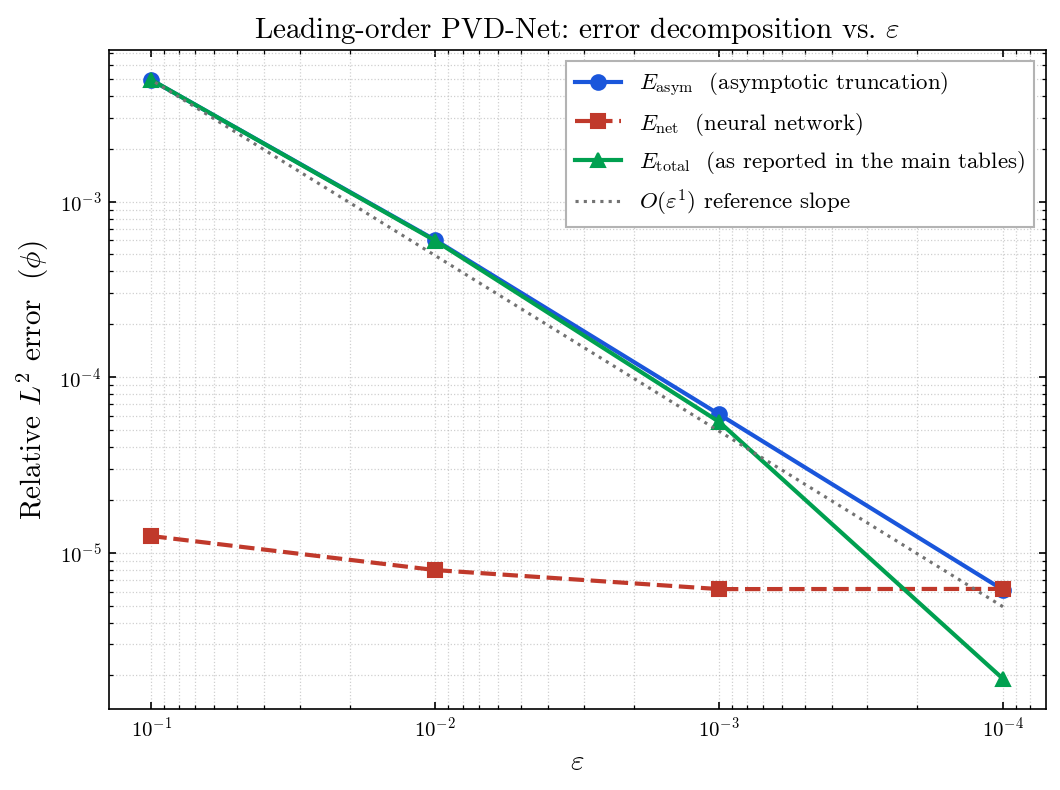

In [15]:
# ============================================================
#  log-log 图: 截断误差 / 网络误差 / 总误差随 ε 的变化
# ============================================================
e_arr = np.array(EPS_LIST, dtype=float)
asym = np.array([sweep[e]['E_asym']['phi'] for e in EPS_LIST])
net = np.array([sweep[e]['E_net']['phi'] for e in EPS_LIST])
tot = np.array([sweep[e]['E_total']['phi'] for e in EPS_LIST])

fig, ax = plt.subplots(figsize=(7.2, 5.4))
ax.loglog(e_arr, asym, 'o-', color=BLUE, lw=2.0, ms=7,
          label=r'$E_{\rm asym}$  (asymptotic truncation)')
ax.loglog(e_arr, net, 's--', color=RED, lw=2.0, ms=7,
          label=r'$E_{\rm net}$  (neural network)')
ax.loglog(e_arr, tot, '^-', color=GREEN, lw=2.0, ms=7,
          label=r'$E_{\rm total}$  (as reported in the main tables)')

# 参考斜线 O(eps^p)
p = 1 if ORDER == 0 else 2
ref_x = np.array([e_arr.min(), e_arr.max()])
c_ref = asym[0] / e_arr[0]**p
ax.loglog(ref_x, c_ref * ref_x**p, ':', color='0.45', lw=1.5,
          label=rf'$O(\varepsilon^{{{p}}})$ reference slope')

ax.set_xlabel(r'$\varepsilon$')
ax.set_ylabel(r'Relative $L^2$ error  ($\phi$)')
ax.set_title(rf'{METHOD_NAME}: error decomposition vs. $\varepsilon$')
ax.invert_xaxis()
ax.grid(True, which='both', ls=':', lw=0.6, alpha=0.6)
ax.legend(loc='best')
fig.tight_layout()
plt.show()

# fig.savefig('eps_scaling.pdf', bbox_inches='tight')
# fig.savefig('eps_scaling.png', bbox_inches='tight')